In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
# Add the head direcoty to sys.path
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../../")

# import this repo's classes
from pyanalib.split_df_helpers import *
import pyanalib.pandas_helpers as ph
from makedf.util import *

sys.path.insert(0, workspace_root + "/../../")
import loaddf
from pot import *
from plot_tools import *
import gump_cuts as gc
import kinematics
from tqdm.auto import tqdm
import importlib
importlib.reload(loaddf)
importlib.reload(gc)

<module 'gump_cuts' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py'>

In [2]:
OUTDIR='/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/EventSelectionPlots/Apr26'

In [3]:
class PlotObj:
  def __init__(self, title, label):
    self.title = title
    self.label = label

# Colors for plots
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [4]:
mode_list = [1, 10, 0]

mode_labels = ["Cosmic", "Dirt", 'Other $\\nu$', '$\\nu_\\mu$ CC RES', '$\\nu_\\mu$ CC MEC', '$\\nu_\\mu$ CC QE']
HAWKS_COLORS = ["#95af8b", "#43140b", "#c89648", "#1e3f54", "#d54c28", "#315031"]

def nuFV(df):
    det = df.detector.iloc[0].split(" ")[0]

    vtx = pd.DataFrame({
        "Run": df.Run,
        "x": df.true_vtx_x,
        "y": df.true_vtx_y,
        "z": df.true_vtx_z,
    })
    return ~np.isnan(df.true_vtx_x) & gc._fv_cut(vtx, det, 0, 0, 0, 0)

def breakdown_mode(var, df):
    """Break down variable by interaction mode."""
    numu_cc = (np.abs(df.true_nu_pdg) == 14) & (df.true_isnc == False)
    fid = nuFV(df)
    fid = ~df.dirt

    ret = [
        var[np.isnan(df.genie_mode)],
        var[~fid & ~np.isnan(df.genie_mode)],
        var[(~np.any([df.genie_mode == i for i in mode_list], axis=0) | ~numu_cc) & fid & ~np.isnan(df.genie_mode)]
    ] +\
        [var[(df.genie_mode == i) & numu_cc & fid] for i in mode_list]
        
    return ret

In [5]:
def make_all_plots(df_nd, df_fd, cut_stage, mode_labels, det_labels):
    sbnd_title = f"{cut_stage}"
    icarus_title = f"{cut_stage}"

    sbnd_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    icarus_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    
    sbnd_comp = plot_mode(df_nd, 'nu_E_calo', sbnd_title, sbnd_file_top, r"$E_{reco}$ [GeV]", mode_labels, det_labels[0], eff_bool=False)
    icarus_comp = plot_mode(df_fd, 'nu_E_calo', icarus_title, icarus_file_top, r"$E_{reco}$ [GeV]", mode_labels, det_labels[1], eff_bool=False)
    sbnd_comp = plot_mode(df_nd, 'del_p', sbnd_title, sbnd_file_top, r"$\delta p$ [GeV]", mode_labels, det_labels[0], eff_bool=False)
    icarus_comp = plot_mode(df_fd, 'del_p', icarus_title, icarus_file_top, r"$\delta p$ [GeV]", mode_labels, det_labels[1], eff_bool=False)
    return sbnd_comp, icarus_comp

def plot_mode(df, var, title, outfile, label, mode_labels, det, eff_bool=False):
    b = np.linspace(0,2.5,21)
    if var == 'nu_E_calo':
        b = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
    var_data = df[var]
    og_sig_ct = df['og_sig_ct'].to_numpy()[0]

    tvar = breakdown_mode(var_data, df)
    glob_scale = breakdown_mode(df['glob_scale'], df)
    # Do purity/efficiency calculation
    ret = [len(t) for t in tvar]
    sig_ct = ret[0]
    tot_ct = sum(ret)
    eff = sig_ct/og_sig_ct
    pur = sig_ct/tot_ct

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    plt.xlabel(label)
    
    if det == "SBND":
        plt.ylabel(r'Events / 50 MeV / $10^{20}$ POT')
    elif det == "ICARUS":
        plt.ylabel(r'Events / 50 MeV / $5\times 10^{20}$ POT')

    bin_widths = b[1:] - b[:-1]

    n = []
    
    for t, g in zip(tvar, glob_scale):
        n_unscaled, _ = np.histogram(t, bins=b, weights=g)
        n.append(n_unscaled)

    n, bins, _ = plt.hist([bin_centers(b) for _ in n], bins=b, weights=[ni/(bin_widths*20) for ni in n], 
                         stacked=True, label=mode_labels, color=HAWKS_COLORS)
    
    #n, bins, _ = plt.hist(tvar, bins=b, stacked=True, label=mode_labels,
    #                    color=HAWKS_COLORS, weights=[g for g in glob_scale])
    
    plt.title(f"$\\bf{{{det}}}$  {title}")
    plt.legend()

    if eff_bool:
        ax.text(0.6, 0.33, f"Composition {{:.2f}}%".format(100*pur),
                transform=ax.transAxes, fontsize=FONTSIZE)
        ax.text(0.6, 0.4, f"Efficiency {{:.2f}}%".format(100*eff),
                transform=ax.transAxes, fontsize=FONTSIZE)
    plt.tight_layout()
    plt.savefig(det+var+title.strip()+'.png')
    plt.show()
    plt.clf()
    return ret/np.sum(ret)

def plot_PID_cut(var, cut_vals, title, outfile, xlims=[0, 100],
                 labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    var_nd, var_fd = var
    cut_val_nd, cut_val_fd = cut_vals
    b = np.linspace(xlims[0], xlims[1], 40)


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    ax1.set_title(title+" Cut")
    plt.subplots_adjust(hspace=0)

    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')
    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    for ax in [ax1, ax2]:
        ax.set_ylabel('Events')
    ax2.set_xlabel(title)
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*1.2
    max_2 = np.max([n3, n4])*1.2
    ax1.vlines(cut_val_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_val_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)
    
    if arrow_dir == 'right':
       ax1.arrow(cut_val_nd, max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd+10, 0.35*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd+10, 0.35*max_2, arrow_txt, color='red')
    elif arrow_dir == 'left':
       ax1.arrow(cut_val_nd, max_1/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd-20, 0.8*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd-20, 0.8*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.savefig(title.strip()+'.png')
    plt.show()
    plt.clf()

def plot_nuscore_cut(var_nd, cut_vals_nd, var_fd, cut_vals_fd, title, outfile, xlims=[0, 100],
                     labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    plt.subplots_adjust(hspace=0)

    b = np.linspace(xlims[0], xlims[1], 40)
    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')

    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    # Style
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='both', direction='in', length=6, width=1.5,  top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.set_ylabel('Events')
    ax2.set_xlabel('Nu Score')
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*3.5
    max_2 = np.max(n4)*3.5
    ax1.vlines(cut_vals_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_vals_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)

    ax1.arrow(cut_vals_nd[0], max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax2.arrow(cut_vals_fd[0], max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax1.text(cut_vals_nd[0]+(xlims[1]-xlims[0])/20, 0.35*max_1, arrow_txt, color='red')
    ax2.text(cut_vals_fd[0]+(xlims[1]-xlims[0])/20, 0.35*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.savefig(title.strip()+'.png')
    plt.show()
    plt.clf()

In [6]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det) & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND")

def FVICARUS(df):
    return FV(df, "ICARUS")



def TrueAV(df, det):
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)
    return gc._fv_cut(vtx, det, 0, 0, 0, 0)

def TrueAVSBND(df):
    return TrueAV(df, "SBND")

def TrueAVICARUS(df):
    return TrueAV(df, "ICARUS")

def OOAVSBND(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVSBND(df)

def OOAVICARUS(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVICARUS(df)

def ICARUS_dirtcut(df):
    # mbox from CV sample
    xlo = -378.49
    ylo = -191.86
    zlo = -904.950652270838

    xhi = 378.49
    yhi = 144.96
    zhi = 904.950652270838
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)

    return ~((vtx.x > xlo) & (vtx.x < xhi) & (vtx.y > ylo) & (vtx.y < yhi) & (vtx.z > zlo) & (vtx.z < zhi))



In [7]:
IGOAL_POT = 5e20
SGOAL_POT = 1e20
RECO = "PANDORA"

DF_DIR = "/exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/"

RUN2_MC_FILES = [DF_DIR + "ICARUSRun2_SpringMCOverlay_rewgt.df"]
RUN4_MC_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]
RUN2_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
RUN4_BEAMOFF_FILES = [DF_DIR + "ICARUSRun2_BNBoff_uncalo_unblind_%i.df" % i for i in range(10)]
RUN2_DIRT_FILES = [DF_DIR + "ICARUSRun2_SpringMCDirt.df"]
RUN4_DIRT_FILES = [DF_DIR + "ICARUSRun4_SpringMCDirt.df"]
RUN2_POT = 2e20
RUN4_POT = 3e20

MC_FILES = [DF_DIR + "SBND_SpringMC_rewgt_5_%i.df" % i for i in range(10)]
BEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData_5000.df"
DIRT_FILE = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/SBND_SpringLowEMC.df"

In [8]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det)# & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND")# & gc.flash_cut(df, "SBND")

def FVICARUSRun2(df):
    return FV(df, "ICARUS Run2")# & gc.flash_cut(df, "ICARUS Run2")

def FVICARUSRun4(df):
    return FV(df, "ICARUS Run4")# & gc.flash_cut(df, "ICARUS Run4")


def containment_cut(df):    
    det = df.detector.iloc[0]
    ret = gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    return ret

In [9]:
df_r2, _, POT_r2 = loaddf.loadl(RUN2_MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVICARUSRun2, detector="ICARUS Run2")
df_r4, _, POT_r4 = loaddf.loadl(RUN4_MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVICARUSRun4, detector="ICARUS Run2")
df_r4['detector'] = "ICARUS Run4"
# Scale each run to its target POT before combining
loaddf.scale_pot(df_r2, POT_r2, RUN2_POT)
loaddf.scale_pot(df_r4, POT_r4, RUN4_POT)
Idf = pd.concat([df_r2, df_r4]).reset_index(drop=True)
Idf['is_offbeam_sample'] = False
Idf['is_dirt_sample'] = False
Ipot = RUN2_POT + RUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
Sdf, Smatch, Spot = loaddf.loadl(MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVSBND, detector="SBND")
Sdf['is_offbeam_sample'] = False
Sdf['is_dirt_sample'] = False

  0%|          | 0/10 [00:00<?, ?it/s]

In [11]:
offbeam_r2, _, offbeampot_r2 = loaddf.load(RUN2_BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun2, offbeampot=True, detector="ICARUS Run2")
offbeam_r4, _, offbeampot_r4 = loaddf.loadl(RUN4_BEAMOFF_FILES, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun4, offbeampot=True, detector="ICARUS Run4", match_Enu=False)
loaddf.scale_pot(offbeam_r2, offbeampot_r2, RUN2_POT)
loaddf.scale_pot(offbeam_r4, offbeampot_r4, RUN4_POT)
Ioffbeam = pd.concat([offbeam_r2, offbeam_r4]).reset_index(drop=True)
Ioffbeam['is_offbeam_sample'] = True
Ioffbeam['is_dirt_sample'] = False
Ioffbeampot = RUN2_POT + RUN4_POT

  0%|          | 0/10 [00:00<?, ?it/s]

In [12]:
Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                      preselection=FVSBND, offbeampot=True, detector="SBND")
Soffbeam['is_offbeam_sample'] = True
Soffbeam['is_dirt_sample'] = False

In [13]:
dirt_r2, _, dirtpot_r2 = loaddf.loadl(RUN2_DIRT_FILES, njob=min(len(RUN2_DIRT_FILES), 10), preselection=FVICARUS, include_syst=False, detector="ICARUS Run2")
dirt_r4, _, dirtpot_r4 = loaddf.loadl(RUN4_DIRT_FILES, njob=min(len(RUN4_DIRT_FILES), 10), preselection=FVICARUS, include_syst=False, detector="ICARUS Run4")
Sdirt, _, Sdirtpot = loaddf.load(DIRT_FILE, preselection=FVSBND, include_syst=False, detector="SBND")
Sdirt['is_offbeam_sample'] = False
Sdirt['is_dirt_sample'] = True

loaddf.scale_pot(dirt_r2, dirtpot_r2, RUN2_POT)
loaddf.scale_pot(dirt_r4, dirtpot_r4, RUN4_POT)
Idirt = pd.concat([dirt_r2, dirt_r4]).reset_index(drop=True)
Idirt['is_offbeam_sample'] = False
Idirt['is_dirt_sample'] = True
Idirtpot = RUN2_POT + RUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
import warnings
from pandas.errors import PerformanceWarning

warnings.filterwarnings('ignore', category=PerformanceWarning)

Idirt = Idirt[ICARUS_dirtcut(Idirt)].copy()

if "dirt" not in Sdf.columns:
    Sdf["dirt"] = False
    Sdirt["dirt"] = True

if "dirt" not in Idf.columns:
    Idf["dirt"] = False
    Idirt["dirt"] = True

loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
loaddf.scale_pot(Sdirt, Sdirtpot, SGOAL_POT)
loaddf.scale_pot(Soffbeam, Soffbeampot, SGOAL_POT)

#loaddf.scale_pot(Idf, Ipot, IGOAL_POT)
#loaddf.scale_pot(Idirt, Idirtpot, IGOAL_POT)
#loaddf.scale_pot(Ioffbeam, Ioffbeampot, IGOAL_POT)

ICARUS_OOT_COSMIC_SCALE = 0.5949386190547118
SBND_OOT_COSMIC_SCALE = 0.9961317495469143

Idf.loc[Idf.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE
Idirt.loc[Idirt.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE

Sdf.loc[Sdf.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE
Sdirt.loc[Sdirt.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE

Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt])
Idf = pd.concat([Idf[~Idf.dirt], Idirt])
#Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt, Soffbeam])
#Idf = pd.concat([Idf[~Idf.dirt], Idirt, Ioffbeam])

In [15]:
df_nd = Sdf.copy()
df_fd = Idf.copy()

#df_nd['glob_scale'] = 1e20/Spot
#df_fd['glob_scale'] = 5e20/Ipot

In [16]:
df_nd['is_sig'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & (df_nd.mu_true_pdg == 13) & (df_nd.p_true_pdg == 2212) & (df_nd.true_nu_pdg == 14) & np.isnan(df_nd.other_shw_length) & np.isnan(df_nd.other_trk_length)
df_fd['is_sig'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & (df_fd.mu_true_pdg == 13) & (df_fd.p_true_pdg == 2212) & (df_fd.true_nu_pdg == 14) & np.isnan(df_fd.other_shw_length) & np.isnan(df_fd.other_trk_length)

df_nd['is_other_numucc'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & ((df_nd.mu_true_pdg != 13) | (df_nd.p_true_pdg != 2212)) & (df_nd.true_nu_pdg == 14)
df_fd['is_other_numucc'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & ((df_fd.mu_true_pdg != 13) | (df_fd.p_true_pdg != 2212)) & (df_fd.true_nu_pdg == 14)

df_nd['is_nc'] = df_nd.true_isnc
df_fd['is_nc'] = df_fd.true_isnc

df_nd['is_fv'] = df_nd.is_contained
df_fd['is_fv'] = df_fd.is_contained

comp_sbnd = []
comp_icarus = []
cut_labels = ["FV Cut", "Flash Cut", "NuScore Cut", "Containment Cut", "Two Prong", "PID"]
det_labels = ("SBND", "ICARUS")

df_nd['og_sig_ct'] = len(df_nd.is_sig[df_nd.is_sig == True])
df_fd['og_sig_ct'] = len(df_fd.is_sig[df_fd.is_sig == True])

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


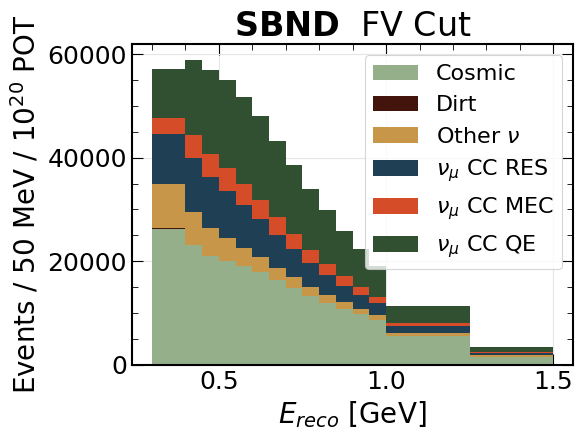

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

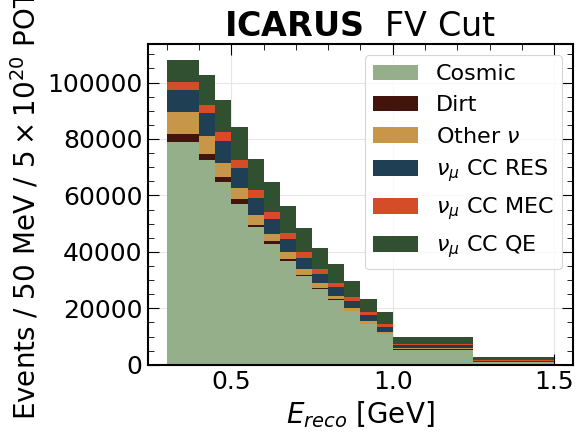

<Figure size 640x480 with 0 Axes>

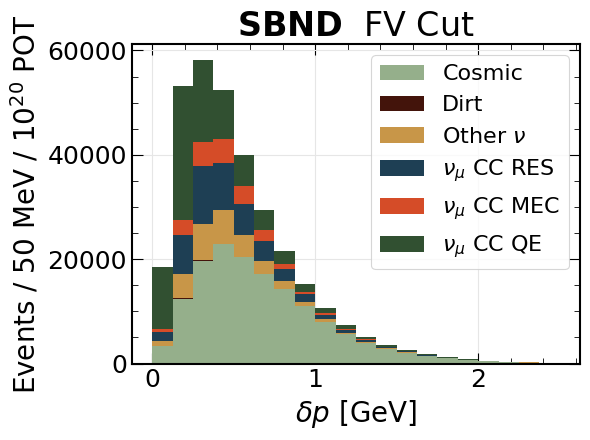

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

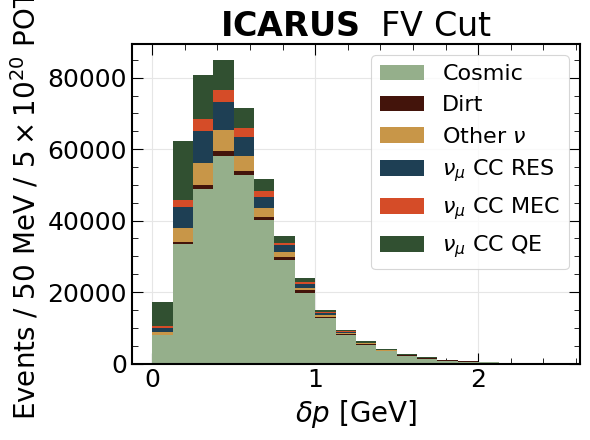

<Figure size 640x480 with 0 Axes>

In [17]:
# FV Cut
df_nd = df_nd[gc.slcfv_cut(df_nd, "SBND")]
df_fd = df_fd[gc.slcfv_cut(df_fd, "ICARUS")]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "FV Cut", mode_labels, det_labels)

comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

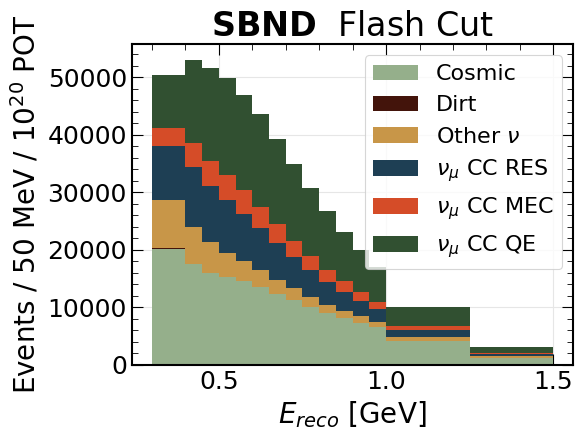

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

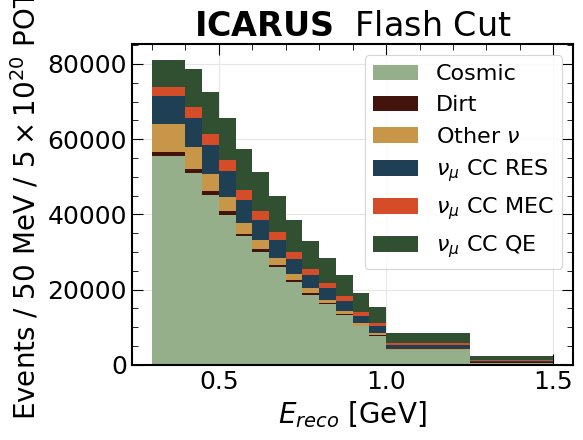

<Figure size 640x480 with 0 Axes>

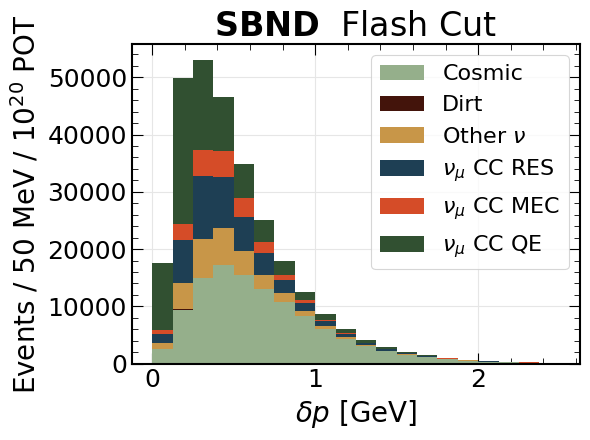

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

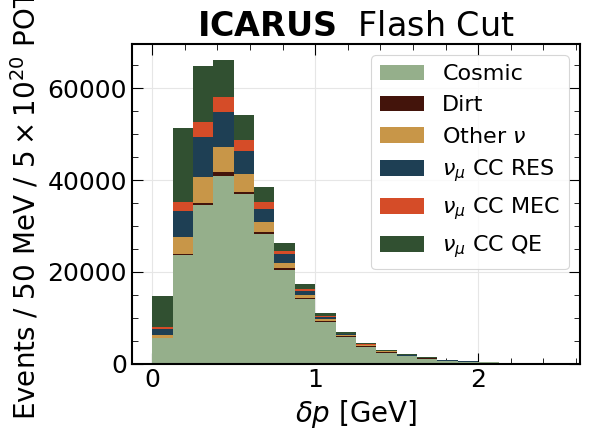

<Figure size 640x480 with 0 Axes>

In [18]:
# Flash Cut
df_nd = df_nd[gc.flash_cut(df_nd, "SBND")]
df_fd = df_fd[gc.flash_cut(df_fd, "ICARUS")]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "Flash Cut", mode_labels, det_labels)

comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

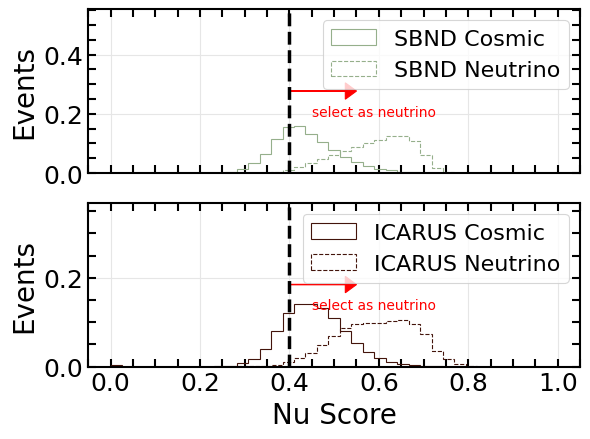

<Figure size 640x480 with 0 Axes>

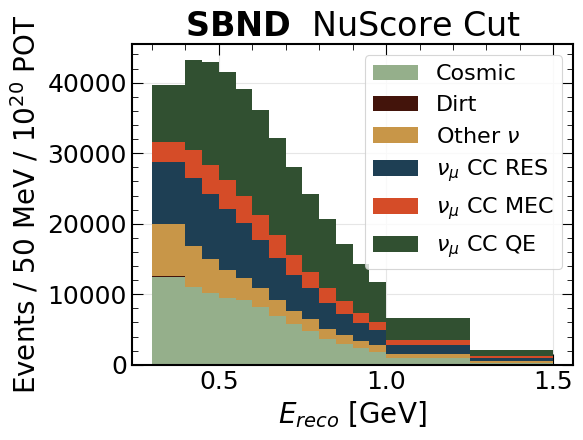

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

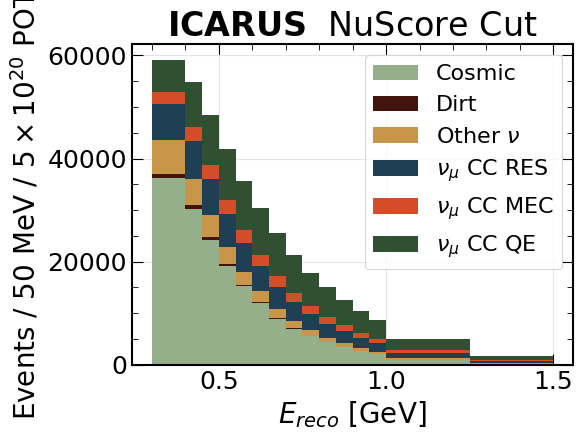

<Figure size 640x480 with 0 Axes>

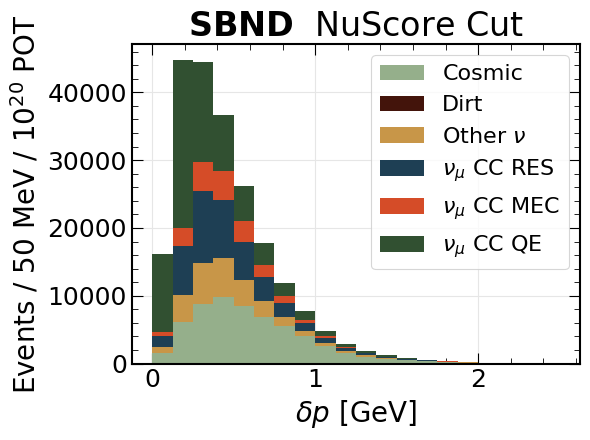

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

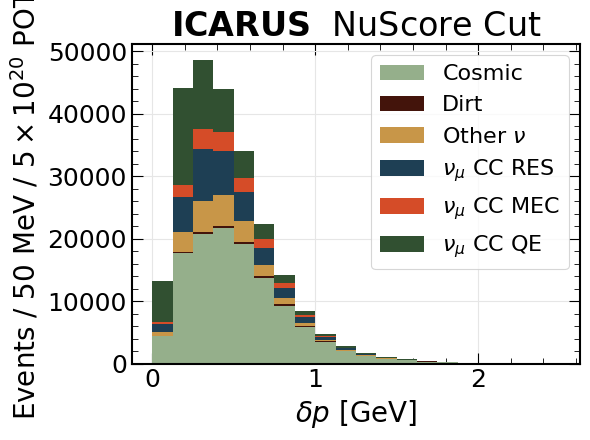

<Figure size 640x480 with 0 Axes>

In [19]:
# NuScore cutnp.isnan(df.genie_mode)
df_nd = add_opening_angle_mu_p(df_nd)
df_fd = add_opening_angle_mu_p(df_fd)

df_nd = df_nd[(df_nd["mu_p_opening_angle_deg"] < 155)]
df_fd = df_fd[(df_fd["mu_p_opening_angle_deg"] < 155)]

plot_nuscore_cut([
    df_nd.nu_score[np.isnan(df_nd.genie_mode)], df_nd.nu_score[~np.isnan(df_nd.genie_mode)]
], [0.4], [
    df_fd.nu_score[np.isnan(df_fd.genie_mode)], df_fd.nu_score[~np.isnan(df_fd.genie_mode)]
], [0.4], "NuScore", "NuScore.png", [0, 1],
    ['SBND Cosmic', 'SBND Neutrino', 'ICARUS Cosmic', 'ICARUS Neutrino'], 'right', 'select as neutrino')

df_nd = df_nd[gc.cosmic_cut(df_nd)]
df_fd = df_fd[gc.cosmic_cut(df_fd)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "NuScore Cut", mode_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

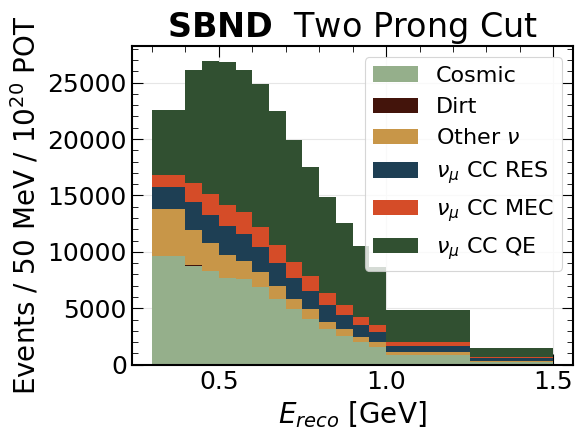

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

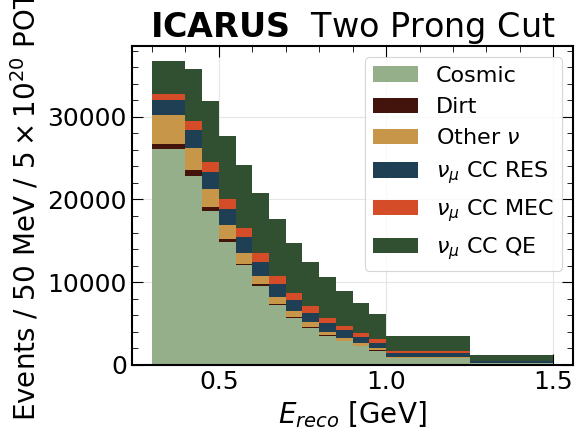

<Figure size 640x480 with 0 Axes>

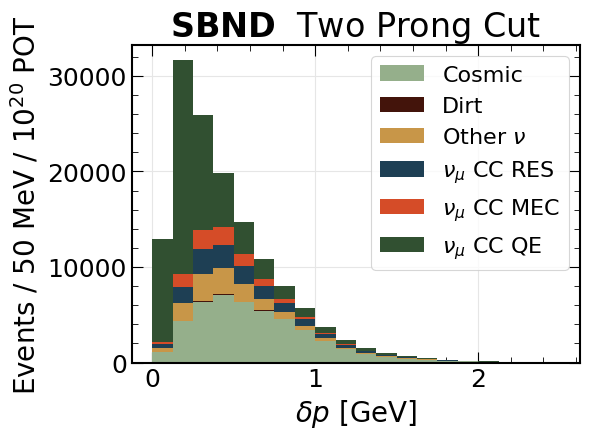

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

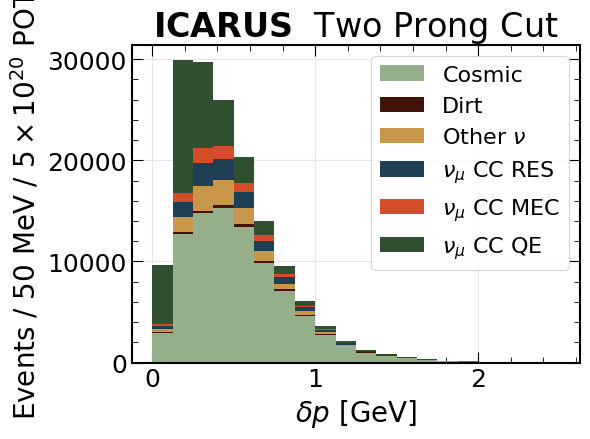

<Figure size 640x480 with 0 Axes>

In [20]:
# Two prong cut
df_nd = df_nd[gc.twoprong_cut(df_nd)]
df_fd = df_fd[gc.twoprong_cut(df_fd)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "Two Prong Cut", mode_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


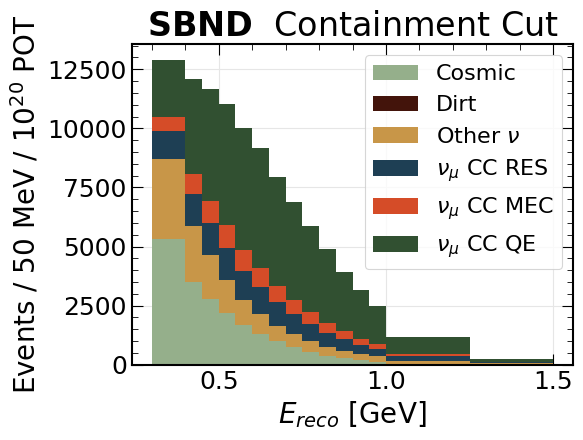

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

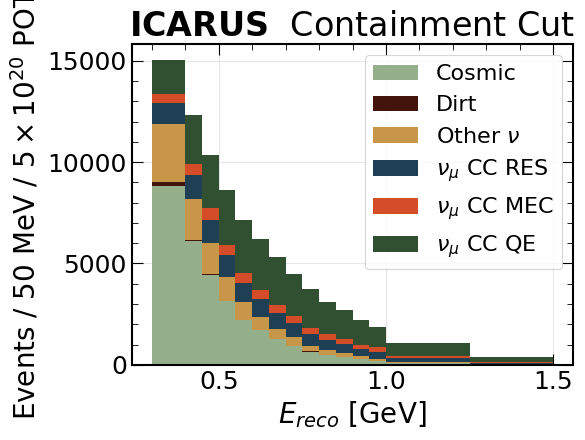

<Figure size 640x480 with 0 Axes>

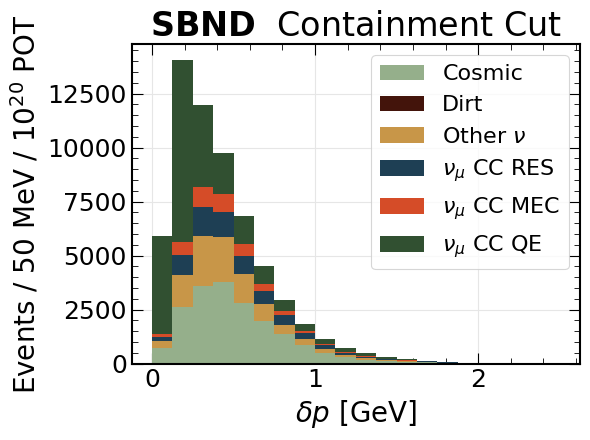

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

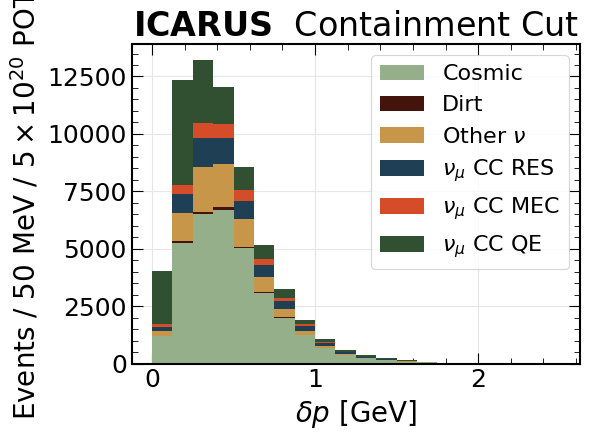

<Figure size 640x480 with 0 Axes>

In [21]:
# Containment Cut
df_nd = df_nd[containment_cut(df_nd)]
df_fd = df_fd[containment_cut(df_fd)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "Containment Cut", mode_labels, det_labels)

comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

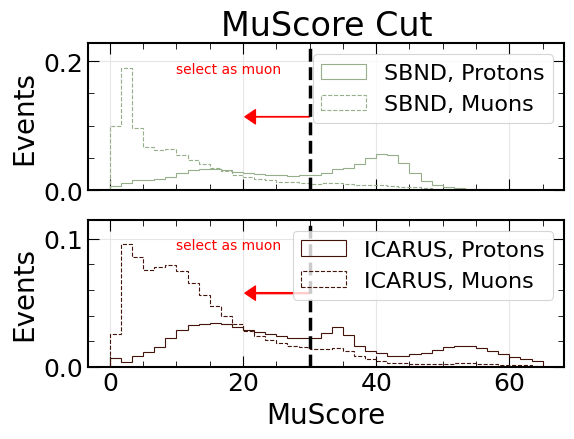

<Figure size 640x480 with 0 Axes>

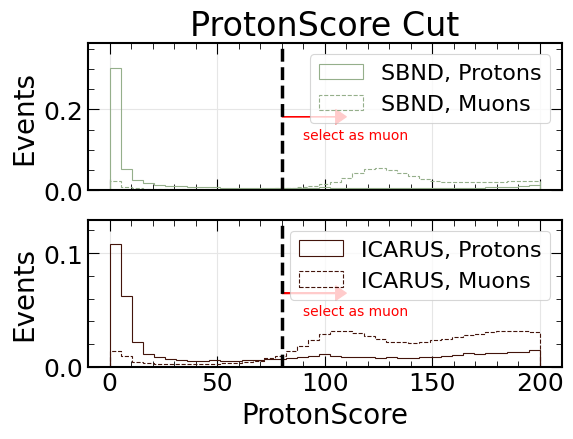

<Figure size 640x480 with 0 Axes>

In [22]:
# PID cuts
plot_PID_cut([[df_nd.mu_chi2_of_prot_cand, df_nd.mu_chi2_of_mu_cand],
              [df_fd.mu_chi2_of_prot_cand, df_fd.mu_chi2_of_mu_cand]],
              [30, 30], "MuScore", "MuScore.png", [0, 65],
              ['SBND, Protons', 'SBND, Muons', 'ICARUS, Protons', 'ICARUS, Muons'],
              'left', 'select as muon')

plot_PID_cut([[df_nd.prot_chi2_of_prot_cand, df_nd.prot_chi2_of_mu_cand],
              [df_fd.prot_chi2_of_prot_cand, df_fd.prot_chi2_of_mu_cand]],
              [80, 80], "ProtonScore", "ProtonScore.png", [0, 200],
              ['SBND, Protons', 'SBND, Muons', 'ICARUS, Protons', 'ICARUS, Muons'],
              'right', 'select as muon')

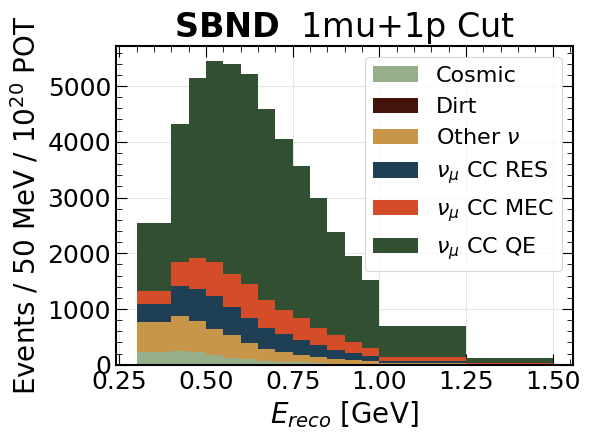

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

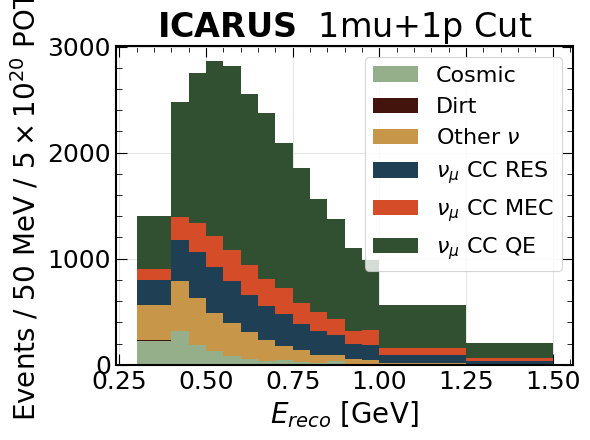

<Figure size 640x480 with 0 Axes>

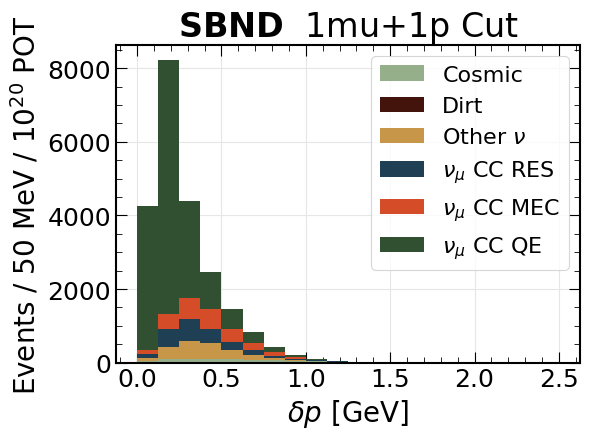

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

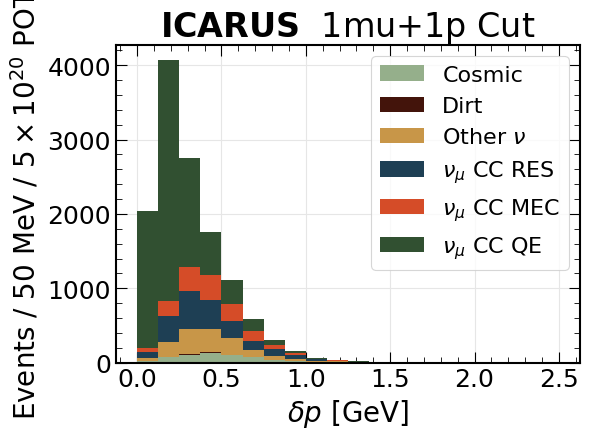

<Figure size 640x480 with 0 Axes>

In [23]:
df_nd = df_nd[gc.pid_cut(df_nd.mu_chi2_of_mu_cand, df_nd.mu_chi2_of_prot_cand, 
                      df_nd.prot_chi2_of_mu_cand, df_nd.prot_chi2_of_prot_cand, df_nd.mu_len)]
df_fd = df_fd[gc.pid_cut(df_fd.mu_chi2_of_mu_cand, df_fd.mu_chi2_of_prot_cand, 
                      df_fd.prot_chi2_of_mu_cand, df_fd.prot_chi2_of_prot_cand, df_fd.mu_len)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "1mu+1p Cut", mode_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

In [16]:
def plot_composition(comp1, comp2, time_labels, components, titles=('SBND', 'ICARUS')):
    # Pre-process data
    data1 = np.flip(np.array(comp1), axis=0)
    data2 = np.flip(np.array(comp2), axis=0)
    
    num_time_points, num_components = data1.shape
    y = np.arange(num_time_points)
    
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(14, 6), gridspec_kw={'wspace': 0.05})
    
    # Define a helper function to plot on a specific axis
    def fill_bars(ax, data, title):
        left = np.zeros(num_time_points)
        for i in range(num_components):
            ax.barh(y, data[:, i], left=left, label=components[i], color=HAWKS_COLORS[i])
            left += data[:, i]
        ax.set_title(title)
        ax.patch.set_alpha(0.0)
        ax.set_facecolor('none')
        ax.set_xlabel('Percentage')
        ax.set_xlim(0, 1)
        ax.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, top=True, right=True)
        ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    # Plot both
    fill_bars(axes[0], data1, titles[0])
    fill_bars(axes[1], data2, titles[1])

    # Set shared Y labels on the first axis only
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(reversed(time_labels))
    
    # --- 1. SET WHITE BACKGROUND ---
    for ax in axes:
        # Set background to solid white (or use (1,1,1,0.5) for semi-transparent)
        ax.set_facecolor('white') 
        
        # --- 2. SET ALL TEXT TO WHITE ---
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
        ax.tick_params(axis='both', which='both', colors='white', labelcolor='white')
        
        # Ensure the spines (borders) are visible/white if needed
        for spine in ax.spines.values():
            spine.set_edgecolor('white')

    # --- 3. HANDLE LEGEND AND TITLE ---
    # Create the legend
    handles, labels = axes[0].get_legend_handles_labels()
    lgd = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
                     ncol=len(components), frameon=False)
    
    # Force legend text to white
    for text in lgd.get_texts():
        text.set_color('white')
        
    # --- SAVE ---
    fig.patch.set_alpha(0.0) # Keeps outside transparent
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig('CombinedComp.png', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()

/tmp/ipykernel_16140/2171607664.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


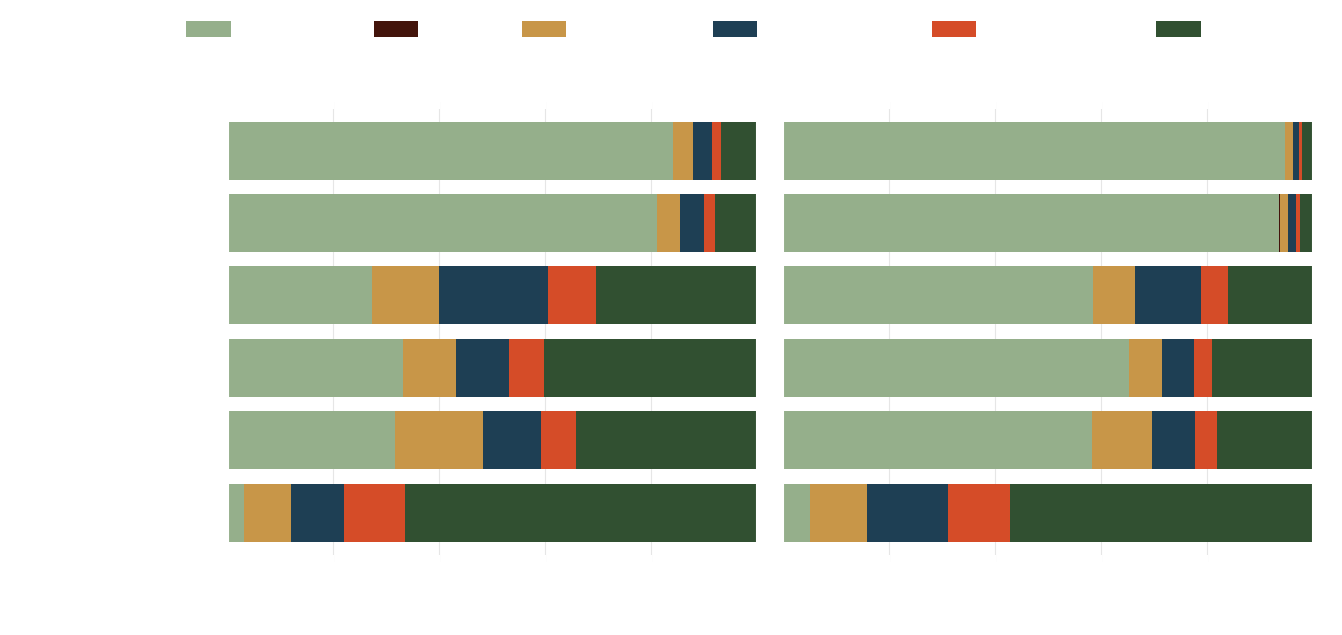

In [38]:
# Composition plots
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')
plot_composition(comp_sbnd, comp_icarus, cut_labels, mode_labels)

In [47]:
del Idirt
del Ioffbeam
del Sdirt
del Soffbeam
del Smatch
del Soffbeammatch
del df_r2
del df_r4
del offbeam_r2
del offbeam_r4

In [48]:
del df_nd
del df_fd
del cutdf_nd
del cutdf_fd

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


         other_shw_length  other_trk_length   slc_vtx_x   slc_vtx_y  \
0                     NaN         45.269279  -32.961582  -38.168579   
1                     NaN               NaN -145.904144  178.918259   
2              149.717224               NaN   33.190056    9.926098   
3               38.764130               NaN   65.636375  158.345795   
4                     NaN               NaN  -56.069889 -159.292236   
...                   ...               ...         ...         ...   
1647545        146.993973               NaN   79.877014  148.052368   
1647546         57.006603               NaN   33.151886  -52.147575   
1647547        204.725647               NaN   33.374207  -65.046021   
1647548        129.691605               NaN  -33.238651  -22.594383   
1647549        169.979233               NaN   54.436192  -42.498783   

          slc_vtx_z  is_clear_cosmic  nu_score  true_pdg  is_cosmic  \
0        149.402054                0  0.537878        14      False   
1    

/tmp/ipykernel_17880/1508725528.py:6: RuntimeWarning: invalid value encountered in subtract
  res_s = df_nd.nu_E_calo.to_numpy() - df_nd.nu_E_true.to_numpy()
/tmp/ipykernel_17880/1508725528.py:7: RuntimeWarning: invalid value encountered in subtract
  res_i = df_fd.nu_E_calo.to_numpy() - df_fd.nu_E_true.to_numpy()


         other_shw_length  other_trk_length   slc_vtx_x   slc_vtx_y  \
0                     NaN         45.269279  -32.961582  -38.168579   
1                     NaN               NaN -145.904144  178.918259   
2              149.717224               NaN   33.190056    9.926098   
3               38.764130               NaN   65.636375  158.345795   
4                     NaN               NaN  -56.069889 -159.292236   
...                   ...               ...         ...         ...   
1647542               NaN               NaN   64.469315  108.757339   
1647543        185.258026               NaN   33.351631   92.987946   
1647544        147.139755               NaN   33.355282  -63.261105   
1647545        146.993973               NaN   79.877014  148.052368   
1647546         57.006603               NaN   33.151886  -52.147575   

          slc_vtx_z  is_clear_cosmic  nu_score  true_pdg  is_cosmic  \
0        149.402054                0  0.537878        14      False   
1    

/tmp/ipykernel_17880/1508725528.py:6: RuntimeWarning: invalid value encountered in subtract
  res_s = df_nd.nu_E_calo.to_numpy() - df_nd.nu_E_true.to_numpy()
/tmp/ipykernel_17880/1508725528.py:7: RuntimeWarning: invalid value encountered in subtract
  res_i = df_fd.nu_E_calo.to_numpy() - df_fd.nu_E_true.to_numpy()
/tmp/ipykernel_17880/1508725528.py:6: RuntimeWarning: invalid value encountered in subtract
  res_s = df_nd.nu_E_calo.to_numpy() - df_nd.nu_E_true.to_numpy()
/tmp/ipykernel_17880/1508725528.py:7: RuntimeWarning: invalid value encountered in subtract
  res_i = df_fd.nu_E_calo.to_numpy() - df_fd.nu_E_true.to_numpy()
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:164: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False True False ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRu

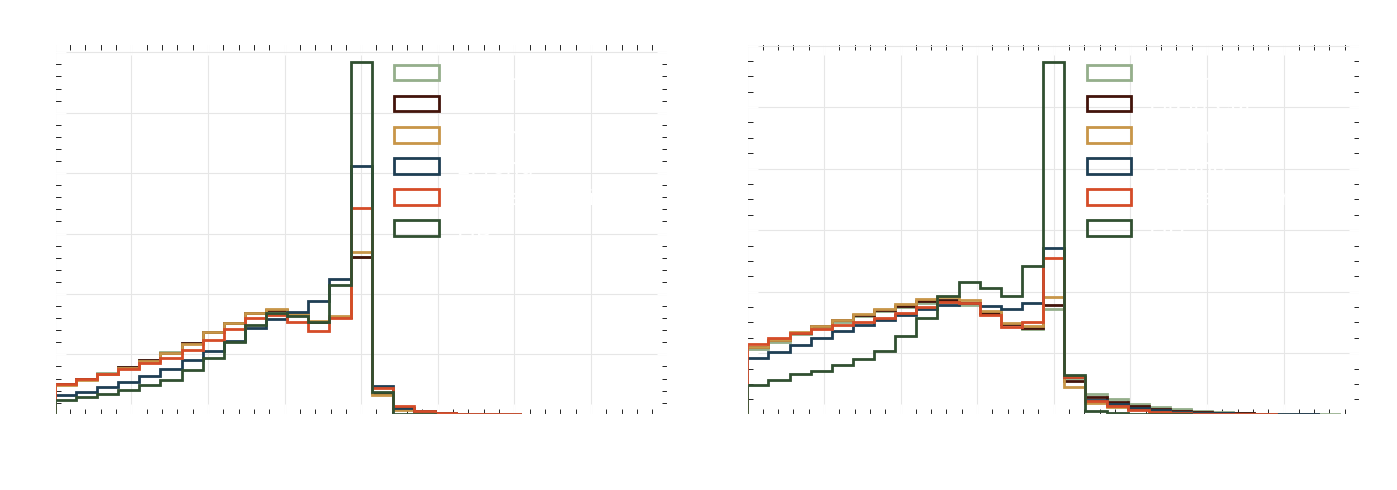

In [49]:
df_nd = Sdf.copy()
df_fd = Idf.copy()

def plot_res(df_nd, df_fd, lbl, ax_s, ax_i):
    # Calculate resolutions
    res_s = df_nd.nu_E_calo.to_numpy() - df_nd.nu_E_true.to_numpy()
    res_i = df_fd.nu_E_calo.to_numpy() - df_fd.nu_E_true.to_numpy()
    
    # Define binning
    b = np.linspace(-1., 1., 30)
    
    # --- FIX: Clip data to bin edges so nothing falls out ---
    res_s = res_s[(res_s > -1) & (res_s < 1)]
    res_i = res_i[(res_i > -1) & (res_i < 1)]
    
    # Plotting
    n, _, _ = ax_s.hist(res_s, bins=b, histtype='step', label=lbl, lw=2, weights=np.ones_like(res_s)/len(res_s))
    ax_i.hist(res_i, bins=b, histtype='step', label=lbl, lw=2, weights=np.ones_like(res_i)/len(res_i))

# --- Setup Figure ---
fig, (ax_sbnd, ax_icarus) = plt.subplots(1, 2, figsize=(14, 5))

## fv cut
cutdf_nd = df_nd[gc.slcfv_cut(df_nd, "SBND")]
cutdf_fd = df_fd[gc.slcfv_cut(df_fd, "ICARUS")]

plot_res(cutdf_nd, cutdf_fd, "FV Cut", ax_sbnd, ax_icarus)

## flash cut
cutdf_nd = cutdf_nd[gc.flash_cut(cutdf_nd, "SBND")]
cutdf_fd = cutdf_fd[gc.flash_cut(cutdf_fd, "ICARUS")]

plot_res(cutdf_nd, cutdf_fd, "Flash Cut", ax_sbnd, ax_icarus)

### NuScore cut
cutdf_nd = df_nd[gc.cosmic_cut(df_nd)]
cutdf_fd = df_fd[gc.cosmic_cut(df_fd)]

plot_res(cutdf_nd, cutdf_fd, "Cosmic Cut", ax_sbnd, ax_icarus)

### Two prong cut
cutdf_nd = cutdf_nd[gc.twoprong_cut(cutdf_nd)]
cutdf_fd = cutdf_fd[gc.twoprong_cut(cutdf_fd)]

plot_res(cutdf_nd, cutdf_fd, "2Prong", ax_sbnd, ax_icarus)

### containment cut
cutdf_nd = df_nd[containment_cut(df_nd)]
cutdf_fd = df_fd[containment_cut(df_fd)]

plot_res(cutdf_nd, cutdf_fd, "Contained Tracks", ax_sbnd, ax_icarus)

### PID cut
cutdf_nd = cutdf_nd[gc.pid_cut(cutdf_nd.mu_chi2_of_mu_cand, cutdf_nd.mu_chi2_of_prot_cand,
                        cutdf_nd.prot_chi2_of_mu_cand, cutdf_nd.prot_chi2_of_prot_cand,
                        cutdf_nd.mu_len)]

cutdf_fd = cutdf_fd[gc.pid_cut(cutdf_fd.mu_chi2_of_mu_cand, cutdf_fd.mu_chi2_of_prot_cand,
                        cutdf_fd.prot_chi2_of_mu_cand, cutdf_fd.prot_chi2_of_prot_cand,
                        cutdf_fd.mu_len)]

plot_res(cutdf_nd, cutdf_fd, "PID", ax_sbnd, ax_icarus)

# --- APPLY FORMATTING (The Clean-up Loop) ---
for ax, ttl in zip([ax_sbnd, ax_icarus], ["SBND", "ICARUS"]):
    # Styling
    ax.set_title(ttl, color='white')
    ax.set_xlabel(r"$E_{calo} - E_{true}$ [GeV]", color='white')
    ax.set_xlim(-1, 1)
    
    # White Ticks & Labels
    ax.tick_params(axis='both', colors='white', labelcolor='white')
    
    # White Spines (the box borders)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        
    # Legend Styling
    leg = ax.legend(frameon=False)
    for text in leg.get_texts():
        text.set_color('white')

    # Formatting
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins='auto', prune='lower'))
    
    # --- Transparency ---
    # Set inside background to white (or use (1,1,1,0.5) for transparency)
    ax.set_facecolor('white') 
    # Make sure we don't have a default grey box
    ax.patch.set_alpha(0.3) # Adjust 0.3 to your preference for "frosted" white

# --- Save with transparency ---
fig.patch.set_alpha(0.0) # Outside figure is fully transparent
plt.tight_layout()
plt.savefig('ERes.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [16]:
del Idirt
del Ioffbeam
del Sdirt
del Soffbeam
del Smatch
del Soffbeammatch
del df_r2
del df_r4
del offbeam_r2
del offbeam_r4

In [17]:
%whos

Variable                      Type         Data/Info
----------------------------------------------------
BEAMOFF_FILE                  str          /exp/sbnd/data/users/nrow<...>_SpringBNBOffData_5000.df
DF_DIR                        str          /exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/
DIRT_FILE                     str          /exp/sbnd/data/users/gput<...>ed-6/SBND_SpringLowEMC.df
FONTSIZE                      int          14
FV                            function     <function FV at 0x7f0a08197f40>
FVICARUS                      function     <function FVICARUS at 0x7f0881e7df30>
FVICARUSRun2                  function     <function FVICARUSRun2 at 0x7f0881e7da20>
FVICARUSRun4                  function     <function FVICARUSRun4 at 0x7f0881e7e320>
FVSBND                        function     <function FVSBND at 0x7f0a08197be0>
HAWKS_COLORS                  list         n=6
ICARUSRun2FVCuts              dict         n=2
ICARUSRun4FVCuts              dict         n=2
ICARUS_OOT_COS

In [19]:
%whos

Variable                      Type         Data/Info
----------------------------------------------------
BEAMOFF_FILE                  str          /exp/sbnd/data/users/nrow<...>_SpringBNBOffData_5000.df
DF_DIR                        str          /exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/
DIRT_FILE                     str          /exp/sbnd/data/users/gput<...>ed-6/SBND_SpringLowEMC.df
FONTSIZE                      int          14
FV                            function     <function FV at 0x7f0a08197f40>
FVICARUS                      function     <function FVICARUS at 0x7f0881e7df30>
FVICARUSRun2                  function     <function FVICARUSRun2 at 0x7f0881e7da20>
FVICARUSRun4                  function     <function FVICARUSRun4 at 0x7f0881e7e320>
FVSBND                        function     <function FVSBND at 0x7f0a08197be0>
HAWKS_COLORS                  list         n=6
ICARUSRun2FVCuts              dict         n=2
ICARUSRun4FVCuts              dict         n=2
ICARUS_OOT_COS